In [6]:
# librerias
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# serie de precios de nvidia del ultimo año
nvda = yf.download('NVDA', period='1y')
nvda

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-02-15,72.637405,73.954033,72.379483,73.848068,420122000
2024-02-16,72.592415,74.380909,72.480447,74.078993,495327000
2024-02-20,69.432312,71.935600,67.714797,71.926600,704833000
2024-02-21,67.452881,68.868480,66.229229,67.986726,690298000
2024-02-22,78.515747,78.552732,74.198970,75.003742,865100000
...,...,...,...,...,...
2025-02-10,133.570007,135.000000,129.960007,130.089996,216989100
2025-02-11,132.800003,134.479996,131.020004,132.580002,178902400


In [8]:
# el df tiene un multiindex, por lo que es necesario ajustar el head del df
nvda.columns = nvda.columns.to_flat_index() # convertir el multiindex en una sola columna
nvda = nvda.rename(columns={('Close', 'NVDA'): 'Close', 
                            ('High', 'NVDA'): 'High', 
                            ('Low', 'NVDA'): 'Low', 
                            ('Open', 'NVDA'): 'Open', 
                            ('Volume', 'NVDA'): 'Volume'}
) # renombrar las columnas

In [9]:
# se resetea el indice de las columnas para convertir la fecha en una columna
nvda = nvda.reset_index()

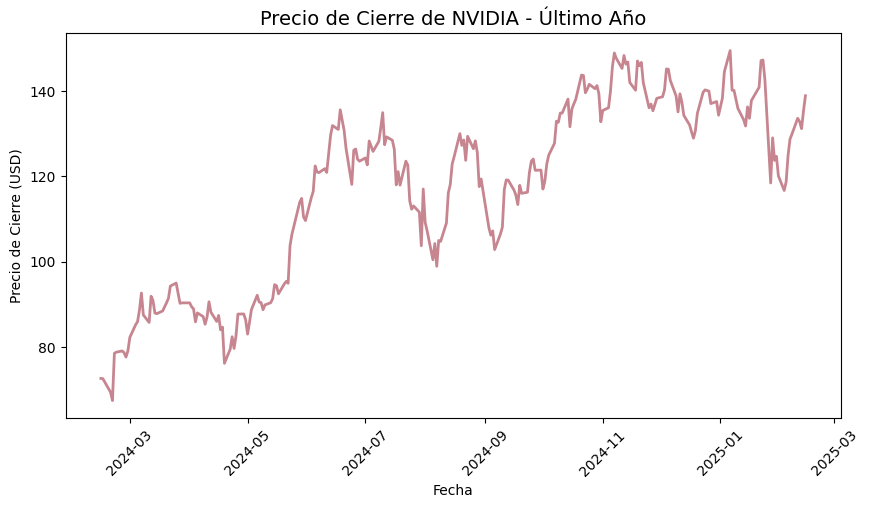

In [10]:
# Configurar el tamaño de la gráfica
plt.figure(figsize=(10, 5))

# Crear gráfica de línea con Seaborn
sns.lineplot(x='Date', y='Close', data=nvda, color='#C78590', linewidth=2)

# Personalizar el gráfico
plt.title('Precio de Cierre de NVIDIA - Último Año', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)

# Guardar la gráfica como imagen estática (opcional, útil para README.md)
plt.savefig("grafica_nvda.png")

# Mostrar la gráfica dentro del notebook
plt.show()
